# Leading-indicator signals to points association across minutes-bands _(population)_
_Read-only EDA: how each leading-indicator signal's Spearman rho with `total_points` behaves across the minutes bands — formula inputs excluded as tautological. No classification, gate, or causal claim._

**Sections:** (a) rho within each minutes band · (b) heatmap — where the association lives

---

`total_points` is a deterministic function of FPL's scoring rules, so correlating a formula input with `total_points` in the same gameweek measures the formula, not player quality — tautological by construction. This notebook restricts to **leading indicators** (`xg`, `xa`, `threat`, `influence`, `creativity`, `clearances_blocks_interceptions`, `tackles`, `recoveries`, `defensive_contribution`) — process proxies that could genuinely fail to associate, so any association found here is informative.

## Setup
> Whole season, `minutes > 0`, DGW excluded; for every (signal, position, band) compute Spearman rho between the leading-indicator signal and `total_points`.

A cell is testable only when the band has n >= 30 and both the signal and `total_points` vary; cameo bands often leave sparse signals untestable (blank), which is itself part of the story.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw
TARGET = "total_points"
MIN_N = 30   # min rows in a (signal, position, band) cell to compute rho

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()   # single-fixture base population

BAND_ORDER = ["1-29", "30-59", "60+"]

def _band(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"

df["band"] = df["minutes"].astype(int).map(_band)

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Leading-indicator signals only: exclude identity/market/structural/context/rolling
# AND all direct FPL formula inputs (correlating formula inputs with total_points
# in the same gameweek is tautological — it measures the scoring formula, not signal quality).
_FORMULA_INPUTS = {
    "goals_scored", "assists", "clean_sheets", "bonus", "bps",
    "saves", "penalties_saved", "penalties_missed", "own_goals",
    "yellow_cards", "red_cards", "goals_conceded",
}
_EXCLUDE = {
    "player_id", "gw", "position_code", "team_id",
    "purchase_price", "minutes", "total_points", "starts",
    "ict_index", "xgi",
    "is_bgw", "is_dgw", "is_warmup_gw",
    "fdr_avg", "xgc", "home_count", "away_count", "fixture_count",
    "is_live", "is_next", "is_previous", "finished",
    "transfers_in", "transfers_out", "ownership_count",
} | _FORMULA_INPUTS
SIGNALS = sorted(
    c for c in df.select_dtypes(include="number").columns
    if c not in _EXCLUDE and "_roll" not in c and not c.endswith("_trend")
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.2f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded, n = {len(df):,} player-gameweeks")
print("Points variance by band (why cameo cells are often untestable):")
for b in BAND_ORDER:
    print(f"  {b}: var(total_points) = {df.loc[df.band == b, TARGET].var():.2f}, n = {int((df.band == b).sum()):,}")
print(f"Signals ({len(SIGNALS)}):", SIGNALS)

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded, n = 11,190 player-gameweeks
Points variance by band (why cameo cells are often untestable):
  1-29: var(total_points) = 1.56, n = 2,553
  30-59: var(total_points) = 2.45, n = 1,030
  60+: var(total_points) = 9.98, n = 7,607
Signals (9): ['clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'influence', 'recoveries', 'tackles', 'threat', 'xa', 'xg']


## (a) Spearman rho (signal ↔ total_points) within each minutes band
> Where on the minutes axis does each leading-indicator signal start tracking points?

Spearman rho per (signal, position, band); cells with n < 30 or no variance are blank (untestable). A rho near 0 in cameos that rises at `60+` means the association only appears in genuine outings; a non-zero cameo rho means the signal carries scoring information even in short appearances (rank-based, season-pooled, not minutes-adjusted).

In [2]:
def _rho_cell(frame, signal):
    """Spearman rho(signal, total_points) on one (position, band) cell, or NaN if
    untestable (too few rows, or no variance in signal or target)."""
    x = frame[signal].astype(float)
    y = frame[TARGET].astype(float)
    if len(frame) < MIN_N or x.nunique() < 2 or y.nunique() < 2:
        return np.nan
    return x.corr(y, method="spearman")

rows = []
for s in SIGNALS:
    for p in POSITIONS:
        for b in BAND_ORDER:
            c = df[(df["position"] == p) & (df["band"] == b)]
            rows.append({"signal": s, "position": p, "band": b,
                         "n": len(c), "rho": _rho_cell(c, s)})
rho_long = pd.DataFrame(rows)
rho_wide = (rho_long.pivot_table(index=["signal", "position"], columns="band",
                                 values="rho", observed=True)
            .reindex(columns=BAND_ORDER))

ncells = len(SIGNALS) * len(POSITIONS)
print(f"Testable (signal, position) cells per band, of {ncells}:")
for b in BAND_ORDER:
    print(f"  {b}: {int(rho_long.loc[rho_long.band == b, 'rho'].notna().sum())}")
display(rho_wide.round(2))

Testable (signal, position) cells per band, of 36:
  1-29: 27
  30-59: 27
  60+: 35


band                                      1-29  30-59   60+
signal                          position                   
clearances_blocks_interceptions DEF      -0.08   0.07  0.26
                                FWD       0.07   0.00  0.04
                                GK         NaN    NaN  0.03
                                MID      -0.07  -0.10  0.14
creativity                      DEF       0.01   0.07  0.01
                                FWD      -0.02  -0.06  0.17
                                GK         NaN    NaN  0.03
                                MID       0.13   0.12  0.17
defensive_contribution          DEF      -0.11   0.08  0.27
                                FWD       0.14  -0.04  0.10
                                MID       0.00  -0.11  0.24
influence                       DEF       0.17   0.30  0.41
                                FWD       0.53   0.55  0.79
                                GK         NaN    NaN  0.33
                                MID       0.33   0.39  0.69
recoveries                      DEF      -0.10   0.04 -0.01
                                FWD       0.16  -0.10  0.07
                                GK         NaN    NaN  0.11
                                MID       0.03  -0.04  0.20
tackles                         DEF      -0.06   0.03  0.05
                                FWD       0.02  -0.05  0.12
                                GK         NaN    NaN -0.06
                                MID       0.02  -0.05  0.16
threat                          DEF       0.17   0.13  0.13
                                FWD       0.41   0.35  0.51
                                GK         NaN    NaN -0.06
                                MID       0.21   0.21  0.30
xa                              DEF       0.09   0.08  0.04
                                FWD       0.01  -0.09  0.18
                                GK         NaN    NaN -0.06
                                MID       0.11   0.13  0.15
xg                              DEF       0.18   0.06  0.14
                                FWD       0.39   0.30  0.46
                                GK         NaN    NaN -0.01
                                MID       0.19   0.18  0.26

## (b) Heatmap — where each signal's association with points lives
> Which signals track points across all bands, and which only at 60+?

The same rho as (a) as a per-position heatmap: rows = signals (sorted by `60+` rho), columns = bands, diverging colour centred at 0 (grey = untestable). A row pale in cameos and bright at `60+` only emerges in genuine outings; a row coloured across all three tracks points even in short appearances.

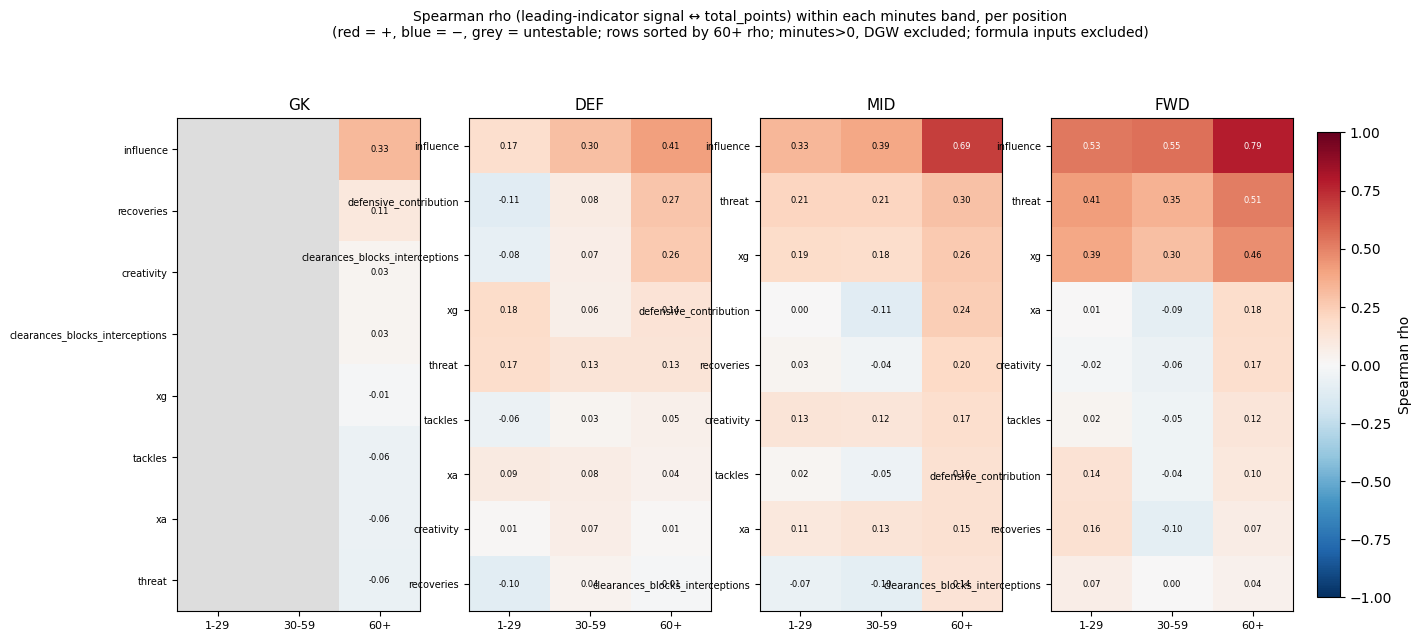

In [3]:
# Heatmap of within-band rho, per position. Diverging colour centred at 0
# (red=+, blue=−); untestable cells grey. Rows sorted by 60+ rho.
cmap = mpl.cm.RdBu_r.copy()
cmap.set_bad("#dddddd")

fig, axes = plt.subplots(1, len(POSITIONS), figsize=(15, 6.4), sharey=False)
for ax, p in zip(axes, POSITIONS):
    mat = rho_wide.xs(p, level="position").reindex(columns=BAND_ORDER)
    mat = mat.loc[mat["60+"].sort_values(ascending=False, na_position="last").index]
    arr = np.ma.masked_invalid(mat.to_numpy(dtype=float))
    im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(BAND_ORDER)))
    ax.set_xticklabels(BAND_ORDER, fontsize=8)
    ax.set_yticks(range(len(mat)))
    ax.set_yticklabels(mat.index, fontsize=7)
    ax.set_title(p, fontsize=11)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if abs(v) > 0.5 else "black")
fig.suptitle("Spearman rho (leading-indicator signal ↔ total_points) within each minutes band, per position\n"
             "(red = +, blue = −, grey = untestable; rows sorted by 60+ rho; minutes>0, DGW excluded; formula inputs excluded)",
             y=1.05, fontsize=10)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Spearman rho")
plt.show()